# Generalising the tuning-curve generative model to D dimensions

The 1-D generative model (clark-presentation / clark-tuning) supposes the tuned
'current' is a periodic Gaussian process, passed through a normalised soft-plus
to give a tuning curve, and fits the hyperparameters $(\sigma, \beta, b)$ by
matching the empirical and sampled tuning-correlation matrices.

This notebook generalises that to **D dimensions**: the current is a GP on a
D-dimensional torus (an isotropic periodic kernel), and the hyperparameters are
fit by matching the empirical and sampled correlation **tensors**, masked to
grid cells that are sufficiently occupied. We look at D = 1, 2 and 4 for one
animal/session, and compare the bases.

In [34]:
import os, numpy as np, polars as pl
import matplotlib.pyplot as plt
from itertools import combinations
import clark_lib as L

ROOT = "/ceph/branco/Jake/training_data_barrier"
DT = 0.025
BEHAVE = ['hdir', 'bdir', 'hsa', 'hba']
P = len(BEHAVE)

## Global configuration (flags, bin counts, grids, visual parameters)

In [35]:
# ---- flags ----
COMPUTE_MODE = 'fresh'      # 'fresh' (recompute + write cache) | 'cache' (load)
OUTPUT_MODE  = 'display'    # 'save' (PNG -> FIG_DIR) | 'display' (inline)
CACHE_DIR = 'generalisation_cache'
FIG_DIR   = 'generalisation_figures'
FIG_DPI   = 120

# ---- which session ----
ANIMAL, SESSION = 0, 0

# ---- discretisation: bins per dimension for each D-model ----
# (small for testing; the final, cached run uses larger values)
N_BINS = {1: 100, 2: 25, 4: 10}

# ---- the variable tuples ('tuning bases') for each D ----
def var_tuples_for_D(D):
    if D == 1: return [(p,) for p in range(P)]
    if D == 2: return list(combinations(range(P), 2))
    if D == 4: return [tuple(range(P))]
    raise ValueError(D)

# ---- cross-validated GP tuning parameters ----
CV_K, CV_L = 2, 2
CV_LENGTH_SCALES = np.logspace(-2, 0, 8)
CV_AMPLITUDES    = np.logspace(-2, 0, 8)
CV_SIGMA = 1.0

# ---- generative-model grid search ----
GEN_SIGMA = np.linspace(0.5, 3.0, 12)
GEN_BETA  = np.linspace(1e-2, 10.0, 12)
GEN_B     = np.linspace(0.0, 4.0, 12)
GEN_N_SAMPLES = 1000
GEN_SEED = 0

# minimum occupancy for a cell to enter the correlation MSE, per D
MIN_COUNT = {1: 1, 2: 5, 4: 3}
# thresholds swept in the D=2 (and D=4) minimum-count analysis
COUNT_SWEEP = [1, 2, 5, 10, 20, 50]

# ---- regression tuning (item 14) ----
REG_L2 = 1.0

# ---- visual parameters ----
FONT = {'suptitle': 17, 'title': 12, 'axis_label': 11, 'tick': 9, 'legend': 9}
COLORS = {
    'behave': {'hdir': '#1f77b4', 'bdir': '#d62728', 'hsa': '#2ca02c', 'hba': '#9467bd'},
    'D': {1: '#1f77b4', 2: '#ff7f0e', 4: '#2ca02c'},
}
CMAP_CORR = 'magma'
CMAP_TUNE = 'viridis'
VAR_NAMES = {'hdir': 'Head direction', 'bdir': 'Barrier direction',
             'hsa': 'Head-shelter angle', 'hba': 'Head-barrier angle'}

plt.rcParams.update({
    'figure.titlesize': FONT['suptitle'], 'axes.titlesize': FONT['title'],
    'axes.labelsize': FONT['axis_label'], 'xtick.labelsize': FONT['tick'],
    'ytick.labelsize': FONT['tick'], 'legend.fontsize': FONT['legend']})

## Compute / cache layer

In [36]:
def load_session(a, s):
    sp = os.path.join(ROOT, str(a), str(s))
    df = pl.scan_csv(os.path.join(sp, 'rates.csv')).collect()
    nc = [c for c in df.columns if c.isdigit()]
    X = df.select(nc).to_numpy().T
    B = df.select(BEHAVE).to_numpy().T
    S = pl.scan_csv(os.path.join(sp, 'spikes.csv')).collect().select(nc).to_numpy().T
    return X, B, S


def regression_tuning(X, B, var_tuples, n_bins, K, L_part, l2):
    """Per-partition L2 (one-hot) regression tuning, averaged over partitions.
    One-hot designs have diagonal normal equations, so the ridge weight for a
    cell is simply (sum of activity in cell) / (count + l2). Returns W (N,n_bases,M)."""
    N, T = X.shape
    D = len(var_tuples[0]); M = n_bins ** D
    bin_idx, _ = L.bin_behaviour(B, n_bins)
    partitions = L._partition_indices(T, K, L_part)
    W = np.full((N, len(var_tuples), M), np.nan)
    for j, vt in enumerate(var_tuples):
        valid = np.all([bin_idx[v] >= 0 for v in vt], axis=0)
        cell = np.zeros(T, int)
        for k, v in enumerate(vt):
            cell += np.where(bin_idx[v] >= 0, bin_idx[v], 0) * (n_bins ** (D - 1 - k))
        cell = np.where(valid, cell, -1)
        acc = np.zeros((N, M)); denom = np.zeros(M)
        for part in partitions:
            c = cell[part]; v = c >= 0; cc = c[v]
            cnt = np.bincount(cc, minlength=M)
            sums = np.zeros((N, M)); np.add.at(sums.T, cc, X[:, part][:, v].T)
            occ = cnt > 0
            acc[:, occ] += sums[:, occ] / (cnt[occ] + l2)
            denom[occ] += 1
        ok = denom > 0
        W[:, j, ok] = acc[:, ok] / denom[ok]
    return W


def compute_D(X, B, S, D):
    """All quantities for one D-model: CV tuning, generative fit, regression tuning."""
    tuples = var_tuples_for_D(D); n_bins = N_BINS[D]
    cv = L.gp_cross_validated_tuning_curves_nd(
        X, B, S, tuples, n_bins=n_bins, K=CV_K, L_part=CV_L,
        length_scales=CV_LENGTH_SCALES, amplitudes=CV_AMPLITUDES, sigma=CV_SIGMA, dt=DT)
    gen = L.fit_torus_generative_model(
        cv['F_best'], cv['counts'], n_bins, D, GEN_SIGMA, GEN_BETA, GEN_B,
        min_count=MIN_COUNT[D], n_samples=GEN_N_SAMPLES, seed=GEN_SEED)
    W = regression_tuning(X, B, tuples, n_bins, CV_K, CV_L, REG_L2)
    return dict(tuples=tuples, n_bins=n_bins, F=cv['F_best'], counts=cv['counts'],
                scores=cv['scores'], bin_idx=cv['bin_idx'], domains=cv['domains'],
                gen=gen, W=W)


def _save_D(d, D):
    np.savez(f"{CACHE_DIR}/D{D}.npz",
             n_bins=d['n_bins'], tuples=np.array(d['tuples']),
             F=d['F'], counts=d['counts'], scores=d['scores'], bin_idx=d['bin_idx'],
             W=d['W'],
             gen_mse=d['gen']['mse'], gen_C=d['gen']['C'], gen_Q=d['gen']['Qcorr_best'],
             gen_masks=d['gen']['valid_masks'],
             gp_sigma=d['gen']['best_params']['sigma'], gp_beta=d['gen']['best_params']['beta'],
             gp_b=d['gen']['best_params']['b'], gp_index=d['gen']['best_params']['index'],
             gen_sigma_values=d['gen']['sigma_values'], gen_beta_values=d['gen']['beta_values'],
             gen_b_values=d['gen']['b_values'])


def _load_D(D):
    z = dict(np.load(f"{CACHE_DIR}/D{D}.npz"))
    return dict(
        n_bins=int(z['n_bins']), tuples=[tuple(t) for t in z['tuples']],
        F=z['F'], counts=z['counts'], scores=z['scores'], bin_idx=z['bin_idx'], W=z['W'],
        gen=dict(mse=z['gen_mse'], C=z['gen_C'], Qcorr_best=z['gen_Q'],
                 valid_masks=z['gen_masks'], sigma_values=z['gen_sigma_values'],
                 beta_values=z['gen_beta_values'], b_values=z['gen_b_values'],
                 best_params=dict(sigma=z['gp_sigma'], beta=z['gp_beta'], b=z['gp_b'],
                                  index=z['gp_index'])))


def compute_or_load():
    if COMPUTE_MODE == 'cache':
        return {D: _load_D(D) for D in (1, 2, 4)}
    os.makedirs(CACHE_DIR, exist_ok=True)
    X, B, S = load_session(ANIMAL, SESSION)
    RES = {}
    for D in (1, 2, 4):
        print(f"=== computing D={D} (n_bins={N_BINS[D]}) ===")
        RES[D] = compute_D(X, B, S, D); _save_D(RES[D], D)
    return RES

RES = compute_or_load()
print("ready:", {D: RES[D]['F'].shape for D in RES})

=== computing D=1 (n_bins=100) ===


D=1 CV tuning:   0%|          | 0/4 [00:00<?, ?basis/s]

D=1 grid search:   0%|          | 0/1728 [00:00<?, ?param/s]

=== computing D=2 (n_bins=25) ===


D=2 CV tuning:   0%|          | 0/6 [00:00<?, ?basis/s]

D=2 grid search:   0%|          | 0/1728 [00:00<?, ?param/s]

=== computing D=4 (n_bins=10) ===


D=4 CV tuning:   0%|          | 0/1 [00:00<?, ?basis/s]

D=4 grid search:   0%|          | 0/1728 [00:00<?, ?param/s]

ready: {1: (116, 4, 100), 2: (116, 6, 625), 4: (116, 1, 10000)}


In [37]:
def finalize(fig, name):
    if OUTPUT_MODE == 'save':
        os.makedirs(FIG_DIR, exist_ok=True)
        path = os.path.join(FIG_DIR, name + '.png')
        fig.savefig(path, dpi=FIG_DPI, bbox_inches='tight'); plt.close(fig)
        print('saved', path)
    else:
        plt.show()

def angle_grid(n_bins):
    return np.linspace(-np.pi, np.pi, n_bins, endpoint=False)

# D = 1

### 0. A random selection of tuning curves per behavioural variable

In [38]:
ITEM0 = dict(n_curves=10, figsize=(16, 4), seed=0, lw=1.2, alpha=0.8)

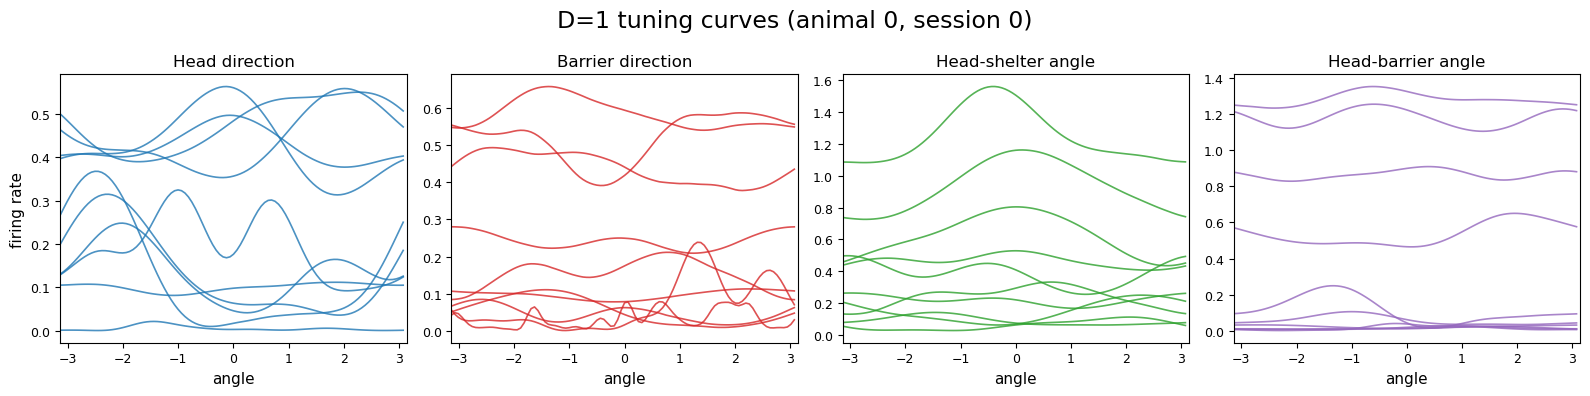

In [39]:
d = RES[1]; x = angle_grid(d['n_bins']); rng = np.random.default_rng(ITEM0['seed'])
fig, axes = plt.subplots(1, P, figsize=ITEM0['figsize'], sharex=True)
for p, v in enumerate(BEHAVE):
    F = d['F'][:, p, :]
    valid = np.where(np.isfinite(F).all(1))[0]
    pick = rng.choice(valid, size=min(ITEM0['n_curves'], valid.size), replace=False)
    for n in pick:
        axes[p].plot(x, F[n], color=COLORS['behave'][v], lw=ITEM0['lw'], alpha=ITEM0['alpha'])
    axes[p].set_title(VAR_NAMES[v]); axes[p].set_xlim(-np.pi, np.pi)
    axes[p].set_xlabel('angle'); axes[0].set_ylabel('firing rate')
fig.suptitle(f'D=1 tuning curves (animal {ANIMAL}, session {SESSION})')
fig.tight_layout(); finalize(fig, 'D1_item0_curves')

### 1. Empirical tuning-correlation matrices

In [40]:
ITEM1 = dict(figsize=(16, 4), cmap=CMAP_CORR)

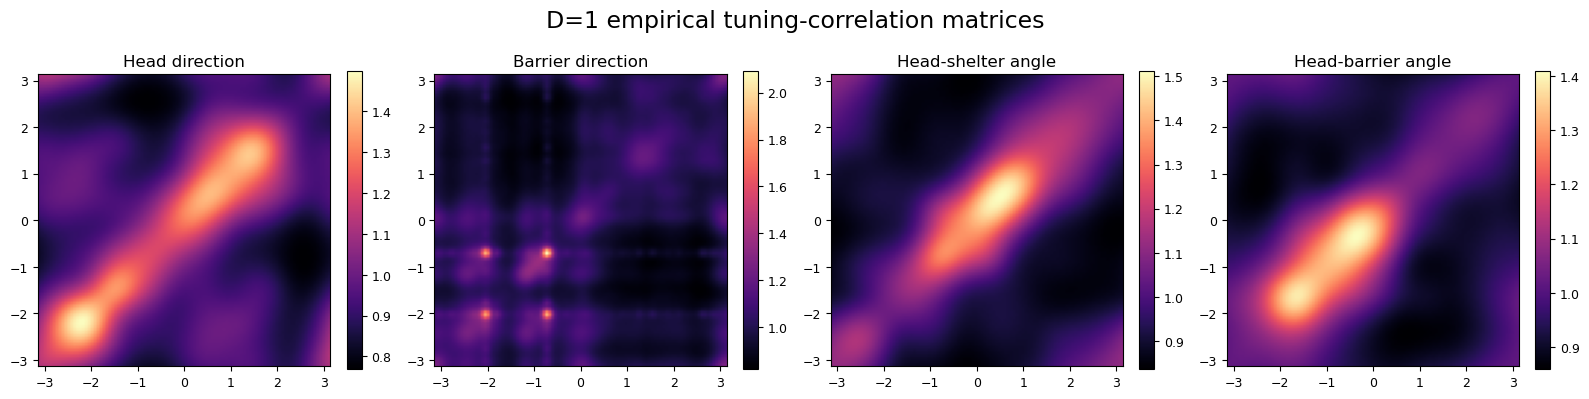

In [41]:
d = RES[1]
fig, axes = plt.subplots(1, P, figsize=ITEM1['figsize'])
for p, v in enumerate(BEHAVE):
    C = d['gen']['C'][p]                      # (M, M) empirical correlation
    im = axes[p].imshow(C, origin='lower', cmap=ITEM1['cmap'],
                        extent=[-np.pi, np.pi, -np.pi, np.pi])
    axes[p].set_title(VAR_NAMES[v]); fig.colorbar(im, ax=axes[p], fraction=0.046)
fig.suptitle('D=1 empirical tuning-correlation matrices')
fig.tight_layout(); finalize(fig, 'D1_item1_corr')

### 2. Sampled correlation matrices for increasing sample size

In [42]:
ITEM2 = dict(sizes=[10, 50, 200, 1000], figsize=(16, 16), cmap=CMAP_CORR, seed=2)

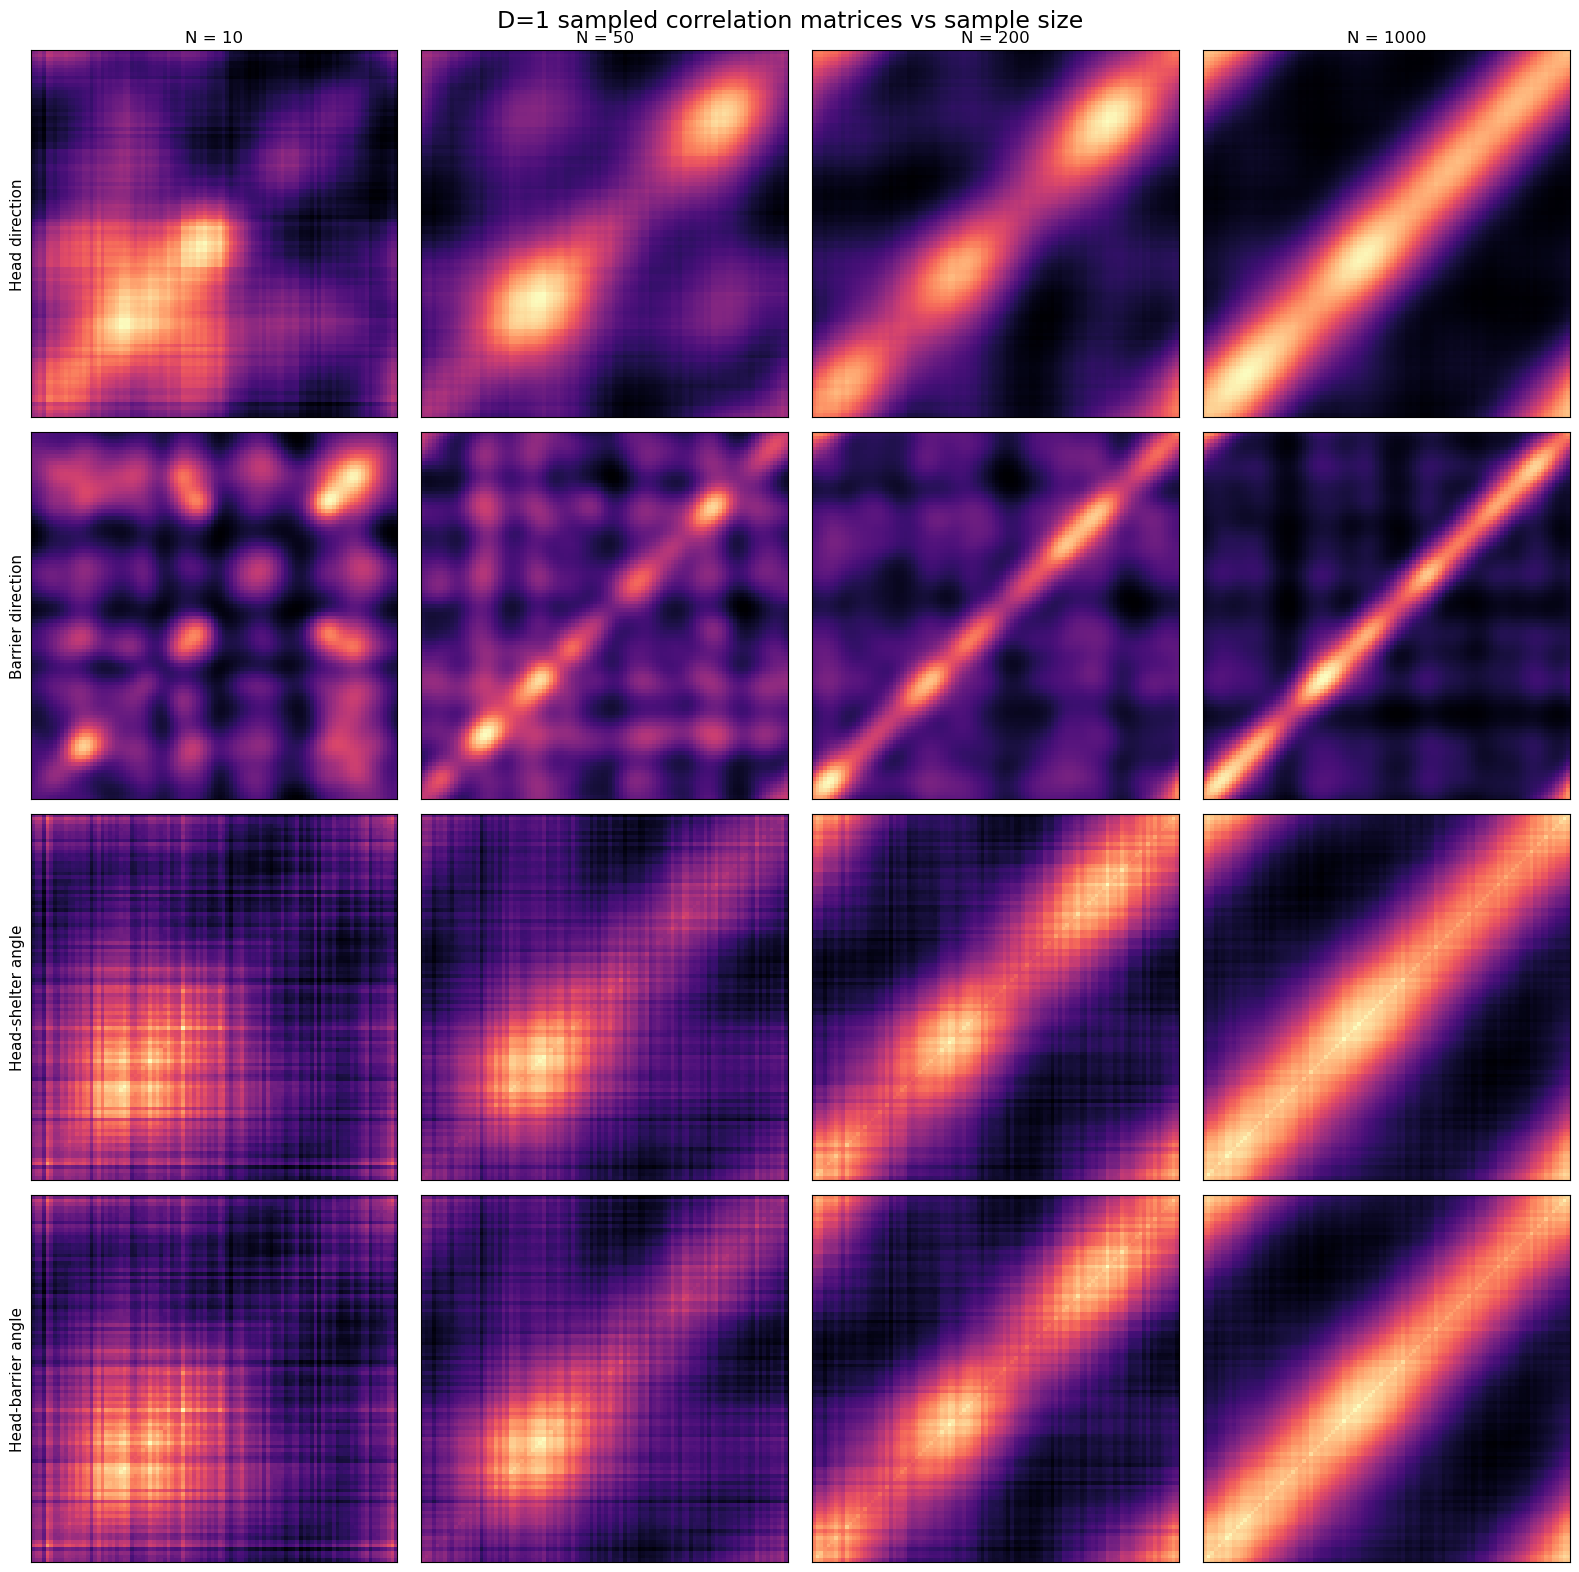

In [43]:
d = RES[1]; gp = d['gen']['best_params']; sizes = ITEM2['sizes']
fig, axes = plt.subplots(P, len(sizes), figsize=ITEM2['figsize'])
for j, Nd in enumerate(sizes):
    for p, v in enumerate(BEHAVE):
        rng = np.random.default_rng(ITEM2['seed'])
        Q = L.sample_torus_tuning_curves(gp['sigma'][p], gp['beta'][p], gp['b'][p],
                                         Nd, 1, d['n_bins'], 1, rng)[:, 0, :]
        C = (Q.T @ Q) / Nd
        axes[p, j].imshow(C, origin='lower', cmap=ITEM2['cmap'])
        axes[p, j].set_xticks([]); axes[p, j].set_yticks([])
        if p == 0: axes[p, j].set_title(f'N = {Nd}')
        if j == 0: axes[p, j].set_ylabel(VAR_NAMES[v])
fig.suptitle('D=1 sampled correlation matrices vs sample size')
fig.tight_layout(); finalize(fig, 'D1_item2_corr_vs_N')

### 3. Hyperparameter grid-search results

Slices through the $(\sigma, \beta, b)$ MSE tensor at the best setting, per
variable; the chosen configuration is marked.

In [44]:
ITEM3 = dict(figsize=(16, 12), cmap='viridis')

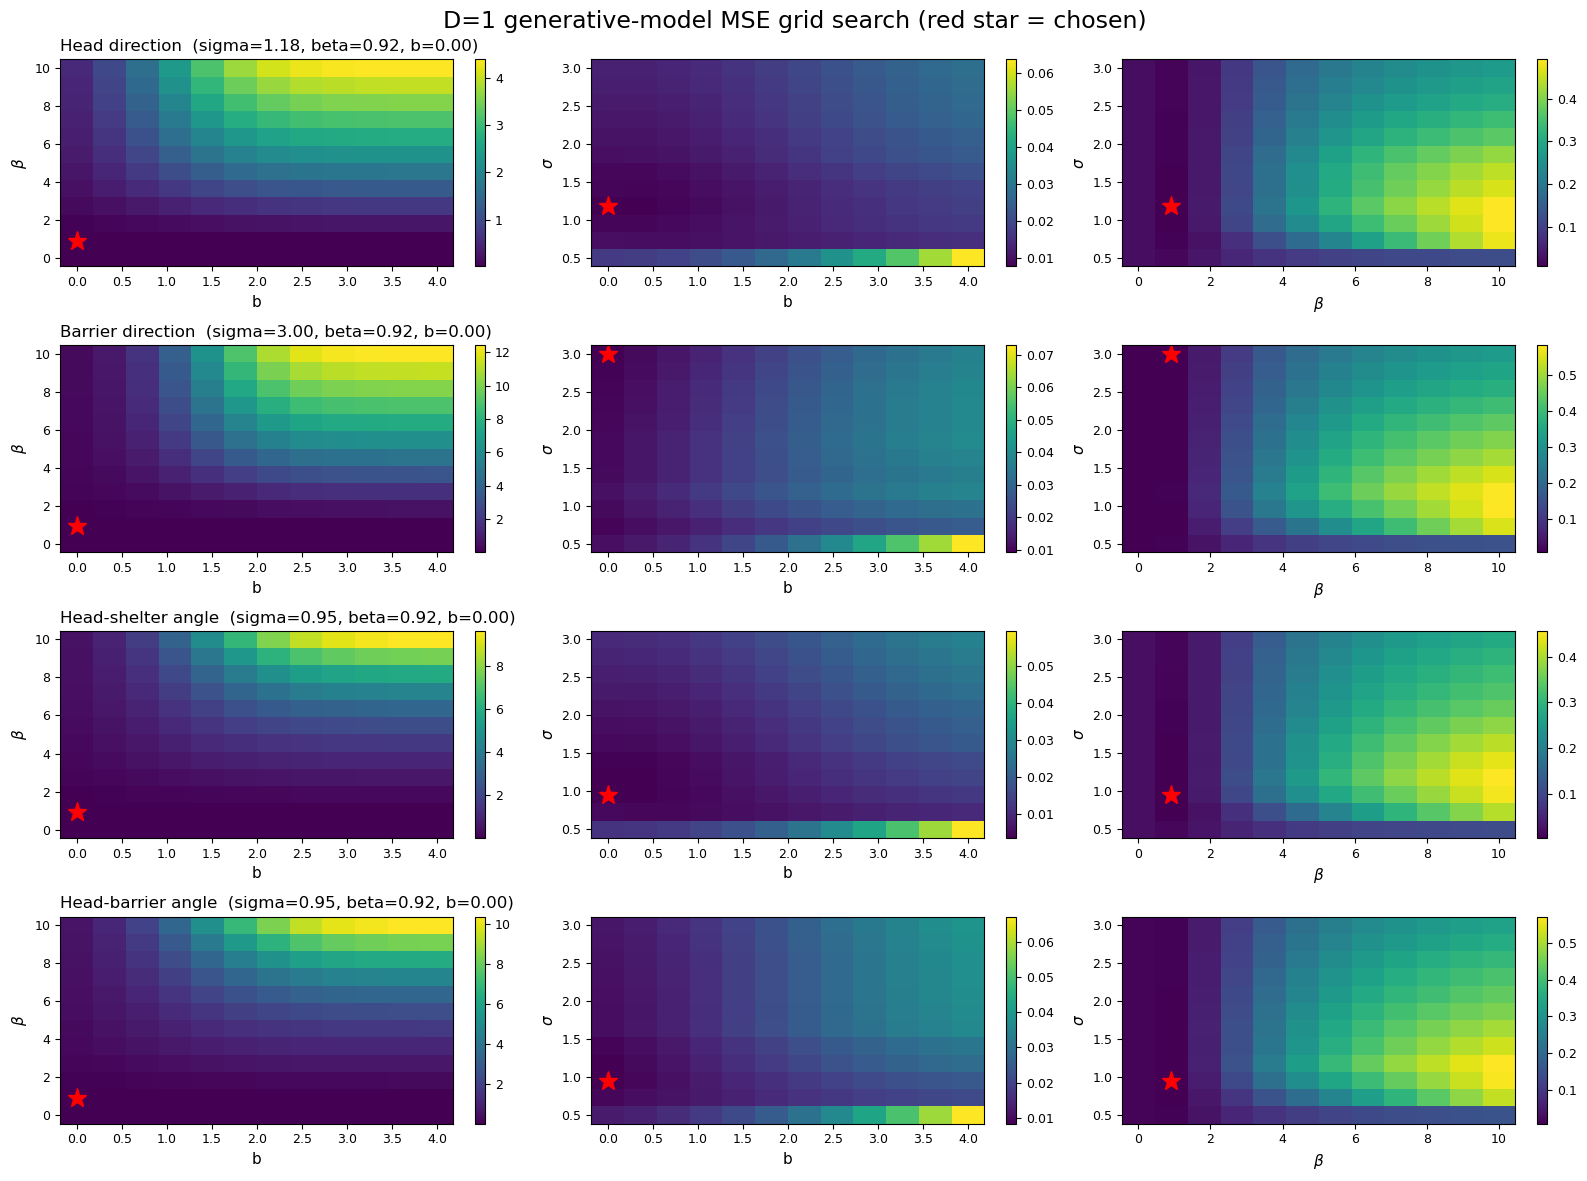

In [45]:
d = RES[1]; gen = d['gen']
sv, bv, bbv = gen['sigma_values'], gen['beta_values'], gen['b_values']
fig, axes = plt.subplots(P, 3, figsize=ITEM3['figsize'])
for p, v in enumerate(BEHAVE):
    mse = gen['mse'][..., p]                      # (n_sigma, n_beta, n_b)
    i_s, i_be, i_b = gen['best_params']['index'][p]
    slices = [(mse[i_s, :, :], (bbv, bv), 'b', r'$\beta$', i_b, i_be),
              (mse[:, i_be, :], (bbv, sv), 'b', r'$\sigma$', i_b, i_s),
              (mse[:, :, i_b], (bv, sv), r'$\beta$', r'$\sigma$', i_be, i_s)]
    for ax, (mat, (xv, yv), xl, yl, ix, iy) in zip(axes[p], slices):
        im = ax.pcolormesh(xv, yv, mat, cmap=ITEM3['cmap'], shading='nearest')
        ax.plot(xv[ix], yv[iy], 'r*', ms=14)
        ax.set_xlabel(xl); ax.set_ylabel(yl)
        fig.colorbar(im, ax=ax, fraction=0.046)
    axes[p, 0].set_title(f"{VAR_NAMES[v]}  "
                         f"(sigma={gen['best_params']['sigma'][p]:.2f}, "
                         f"beta={gen['best_params']['beta'][p]:.2f}, "
                         f"b={gen['best_params']['b'][p]:.2f})", loc='left')
fig.suptitle('D=1 generative-model MSE grid search (red star = chosen)')
fig.tight_layout(); finalize(fig, 'D1_item3_gridsearch')

# D = 2

### 3.5. A random sample of joint tuning curves for each variable pair

In [46]:
ITEM35 = dict(n_curves=5, figsize=(14, 16), seed=0, cmap=CMAP_TUNE)

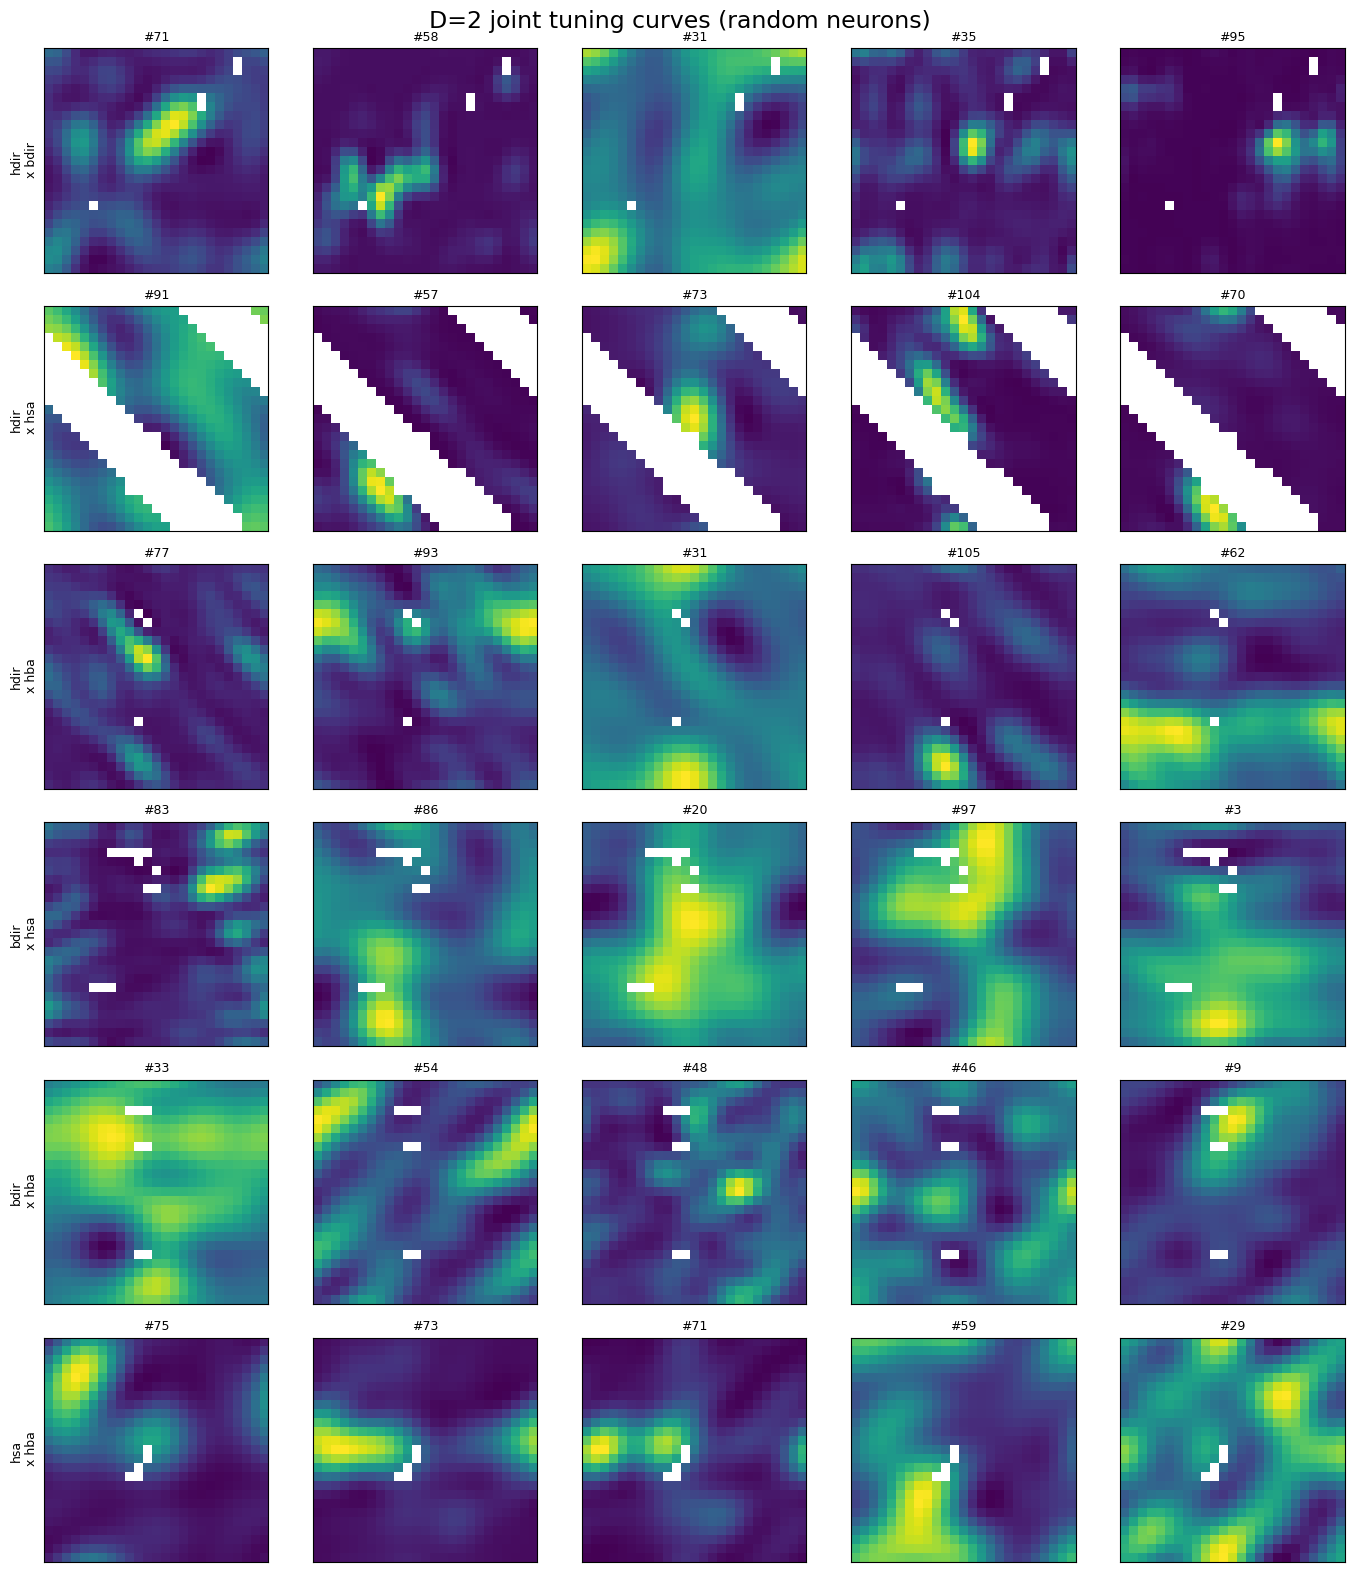

In [47]:
d = RES[2]; B = d['n_bins']; rng = np.random.default_rng(ITEM35['seed'])
maps = d['F'].reshape(d['F'].shape[0], len(d['tuples']), B, B)
ext = [-np.pi, np.pi, -np.pi, np.pi]
fig, axes = plt.subplots(len(d['tuples']), ITEM35['n_curves'], figsize=ITEM35['figsize'])
for j, (p, q) in enumerate(d['tuples']):
    valid = np.where(np.isfinite(maps[:, j]).any(axis=(1, 2)))[0]
    pick = rng.choice(valid, size=min(ITEM35['n_curves'], valid.size), replace=False)
    for c, n in enumerate(pick):
        axes[j, c].imshow(maps[n, j], origin='lower', extent=ext, cmap=ITEM35['cmap'])
        axes[j, c].set_xticks([]); axes[j, c].set_yticks([])
        if c == 0:
            axes[j, c].set_ylabel(f"{BEHAVE[p]}\n x {BEHAVE[q]}", fontsize=FONT['tick'])
        axes[j, c].set_title(f'#{n}', fontsize=FONT['tick'])
fig.suptitle('D=2 joint tuning curves (random neurons)')
fig.tight_layout(); finalize(fig, 'D2_item35_curves')

### 4. Bin counts (occupancy) for each pair

In [48]:
ITEM4 = dict(figsize=(16, 3), cmap='cividis')

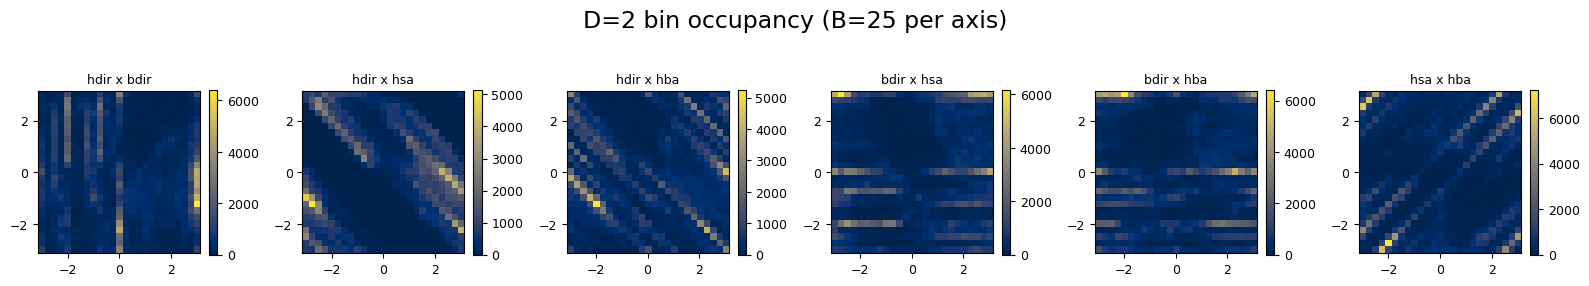

In [49]:
d = RES[2]; B = d['n_bins']
counts = d['counts'].reshape(len(d['tuples']), B, B)
ext = [-np.pi, np.pi, -np.pi, np.pi]
fig, axes = plt.subplots(1, len(d['tuples']), figsize=ITEM4['figsize'])
for j, (p, q) in enumerate(d['tuples']):
    im = axes[j].imshow(counts[j], origin='lower', extent=ext, cmap=ITEM4['cmap'])
    axes[j].set_title(f"{BEHAVE[p]} x {BEHAVE[q]}", fontsize=FONT['tick'])
    fig.colorbar(im, ax=axes[j], fraction=0.046)
fig.suptitle(f'D=2 bin occupancy (B={B} per axis)')
fig.tight_layout(); finalize(fig, 'D2_item4_counts')

### 5. Sweeping the minimum-count threshold

We re-fit the generative model while varying the minimum occupancy required for
a cell to enter the MSE, and plot the best MSE obtained at each threshold.

In [50]:
ITEM5 = dict(thresholds=COUNT_SWEEP, n_samples=400, figsize=(8, 5), seed=GEN_SEED)

D=2 grid search:   0%|          | 0/1728 [00:00<?, ?param/s]

D=2 grid search:   0%|          | 0/1728 [00:00<?, ?param/s]

D=2 grid search:   0%|          | 0/1728 [00:00<?, ?param/s]

D=2 grid search:   0%|          | 0/1728 [00:00<?, ?param/s]

D=2 grid search:   0%|          | 0/1728 [00:00<?, ?param/s]

D=2 grid search:   0%|          | 0/1728 [00:00<?, ?param/s]

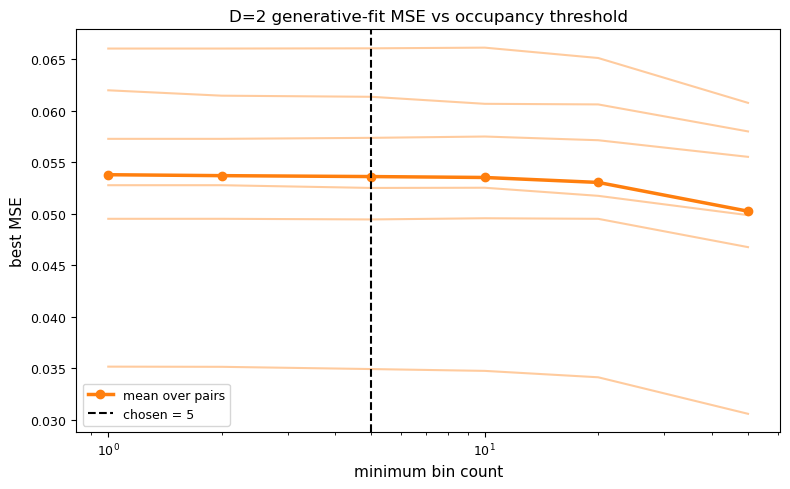

In [51]:
d = RES[2]; thr = ITEM5['thresholds']
sweep = np.full((len(thr), len(d['tuples'])), np.nan)
for ti, t in enumerate(thr):
    g = L.fit_torus_generative_model(d['F'], d['counts'], d['n_bins'], 2,
            GEN_SIGMA, GEN_BETA, GEN_B, min_count=t, n_samples=ITEM5['n_samples'],
            seed=ITEM5['seed'], return_corr=False)
    sweep[ti] = g['best_params']['mse']
fig, ax = plt.subplots(figsize=ITEM5['figsize'])
for j, (p, q) in enumerate(d['tuples']):
    ax.plot(thr, sweep[:, j], '-', alpha=0.4, color=COLORS['D'][2])
ax.plot(thr, sweep.mean(1), '-o', color=COLORS['D'][2], lw=2.5, label='mean over pairs')
ax.axvline(MIN_COUNT[2], ls='--', color='k', label=f"chosen = {MIN_COUNT[2]}")
ax.set_xlabel('minimum bin count'); ax.set_ylabel('best MSE'); ax.set_xscale('log')
ax.legend(); ax.set_title('D=2 generative-fit MSE vs occupancy threshold')
fig.tight_layout(); finalize(fig, 'D2_item5_threshold_sweep')

### 6. Empirical tuning-correlation matrices (all pairs)

In [52]:
ITEM6 = dict(figsize=(16, 3), cmap=CMAP_CORR)

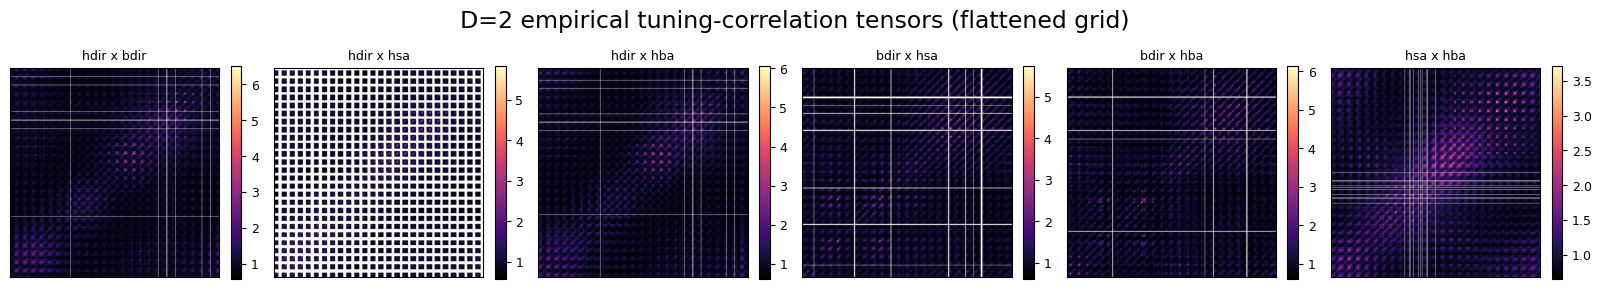

In [53]:
d = RES[2]
fig, axes = plt.subplots(1, len(d['tuples']), figsize=ITEM6['figsize'])
for j, (p, q) in enumerate(d['tuples']):
    im = axes[j].imshow(d['gen']['C'][j], origin='lower', cmap=ITEM6['cmap'])
    axes[j].set_title(f"{BEHAVE[p]} x {BEHAVE[q]}", fontsize=FONT['tick'])
    axes[j].set_xticks([]); axes[j].set_yticks([])
    fig.colorbar(im, ax=axes[j], fraction=0.046)
fig.suptitle('D=2 empirical tuning-correlation tensors (flattened grid)')
fig.tight_layout(); finalize(fig, 'D2_item6_corr')

### 7. Sampled correlation tensors for increasing sample size

In [54]:
ITEM7 = dict(sizes=[10, 50, 200, 1000], figsize=(14, 16), cmap=CMAP_CORR, seed=2)

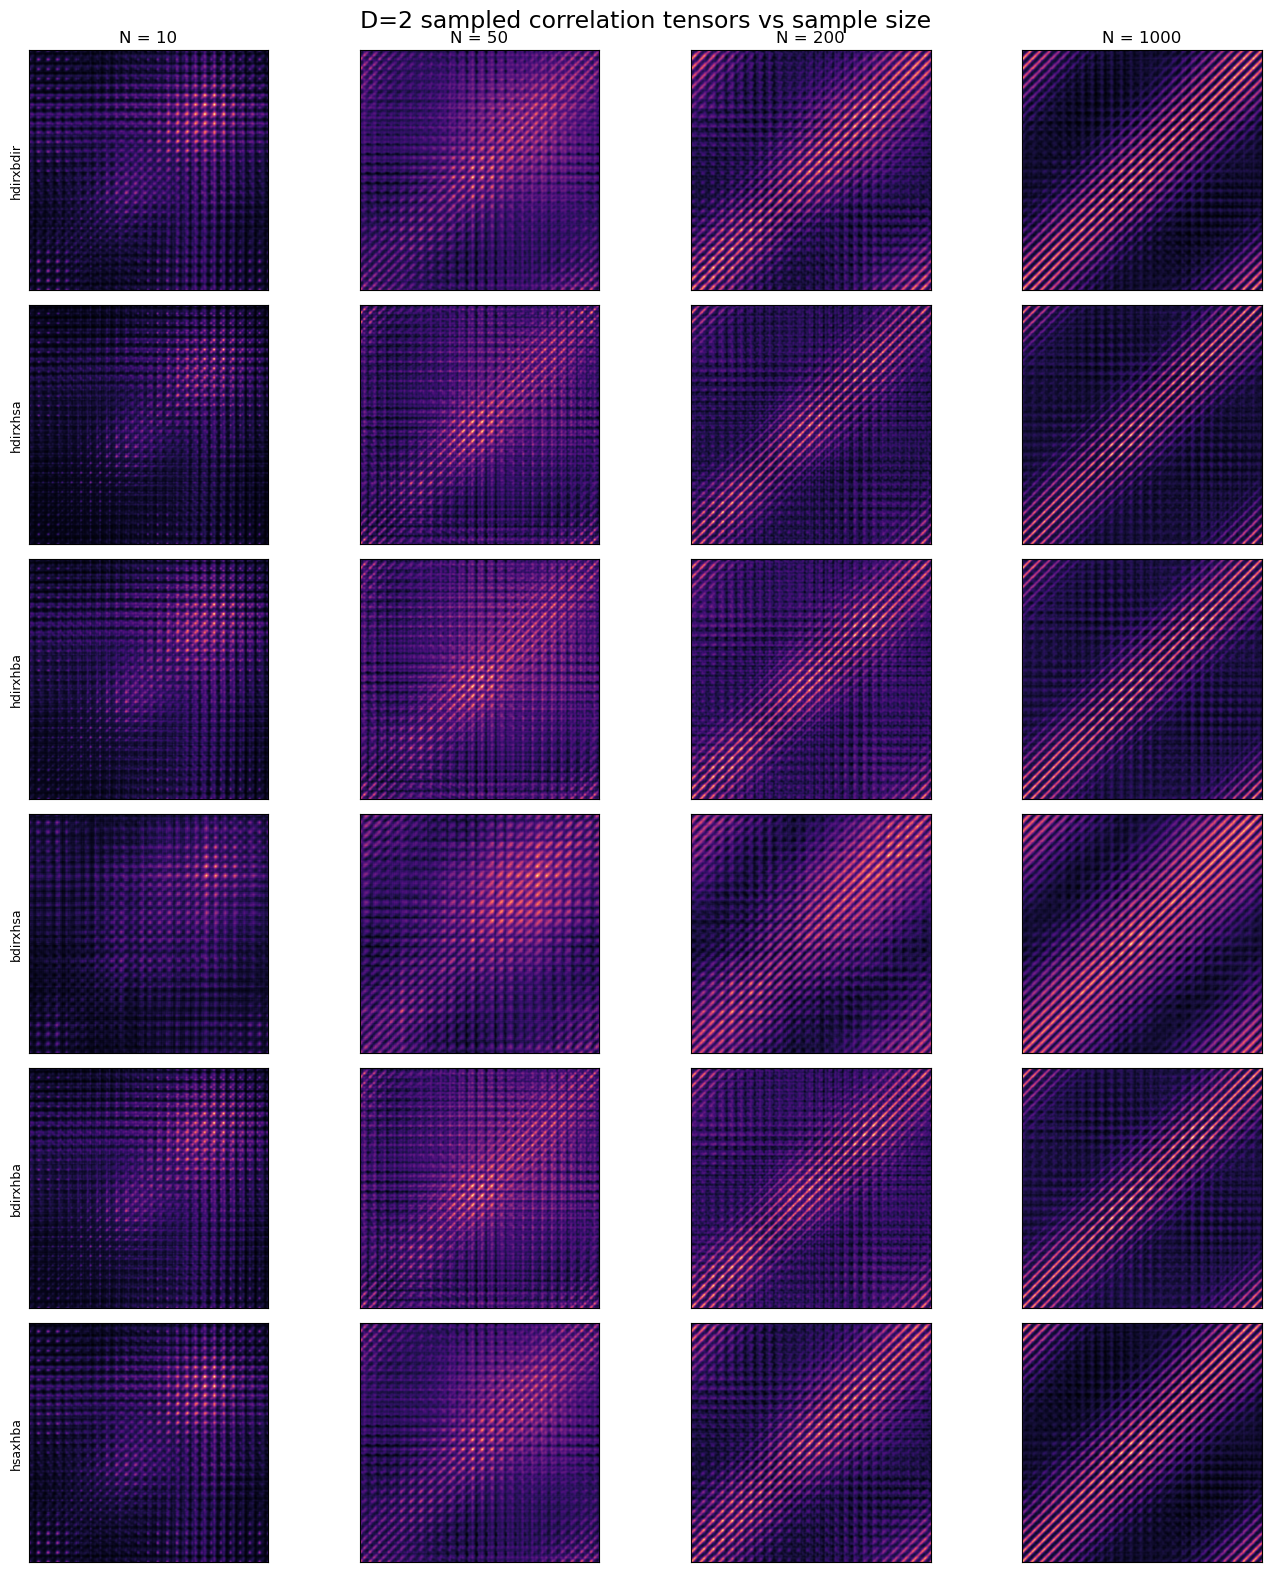

In [55]:
d = RES[2]; gp = d['gen']['best_params']; sizes = ITEM7['sizes']; B = d['n_bins']
fig, axes = plt.subplots(len(d['tuples']), len(sizes), figsize=ITEM7['figsize'])
for jcol, Nd in enumerate(sizes):
    for j, (p, q) in enumerate(d['tuples']):
        rng = np.random.default_rng(ITEM7['seed'])
        Q = L.sample_torus_tuning_curves(gp['sigma'][j], gp['beta'][j], gp['b'][j],
                                         Nd, 1, B, 2, rng)[:, 0, :]
        C = (Q.T @ Q) / Nd
        axes[j, jcol].imshow(C, origin='lower', cmap=ITEM7['cmap'])
        axes[j, jcol].set_xticks([]); axes[j, jcol].set_yticks([])
        if j == 0: axes[j, jcol].set_title(f'N = {Nd}')
        if jcol == 0: axes[j, jcol].set_ylabel(f"{BEHAVE[p]}x{BEHAVE[q]}", fontsize=FONT['tick'])
fig.suptitle('D=2 sampled correlation tensors vs sample size')
fig.tight_layout(); finalize(fig, 'D2_item7_corr_vs_N')

### 8. Hyperparameter grid-search results (all pairs)

In [56]:
ITEM8 = dict(figsize=(16, 18), cmap='viridis')

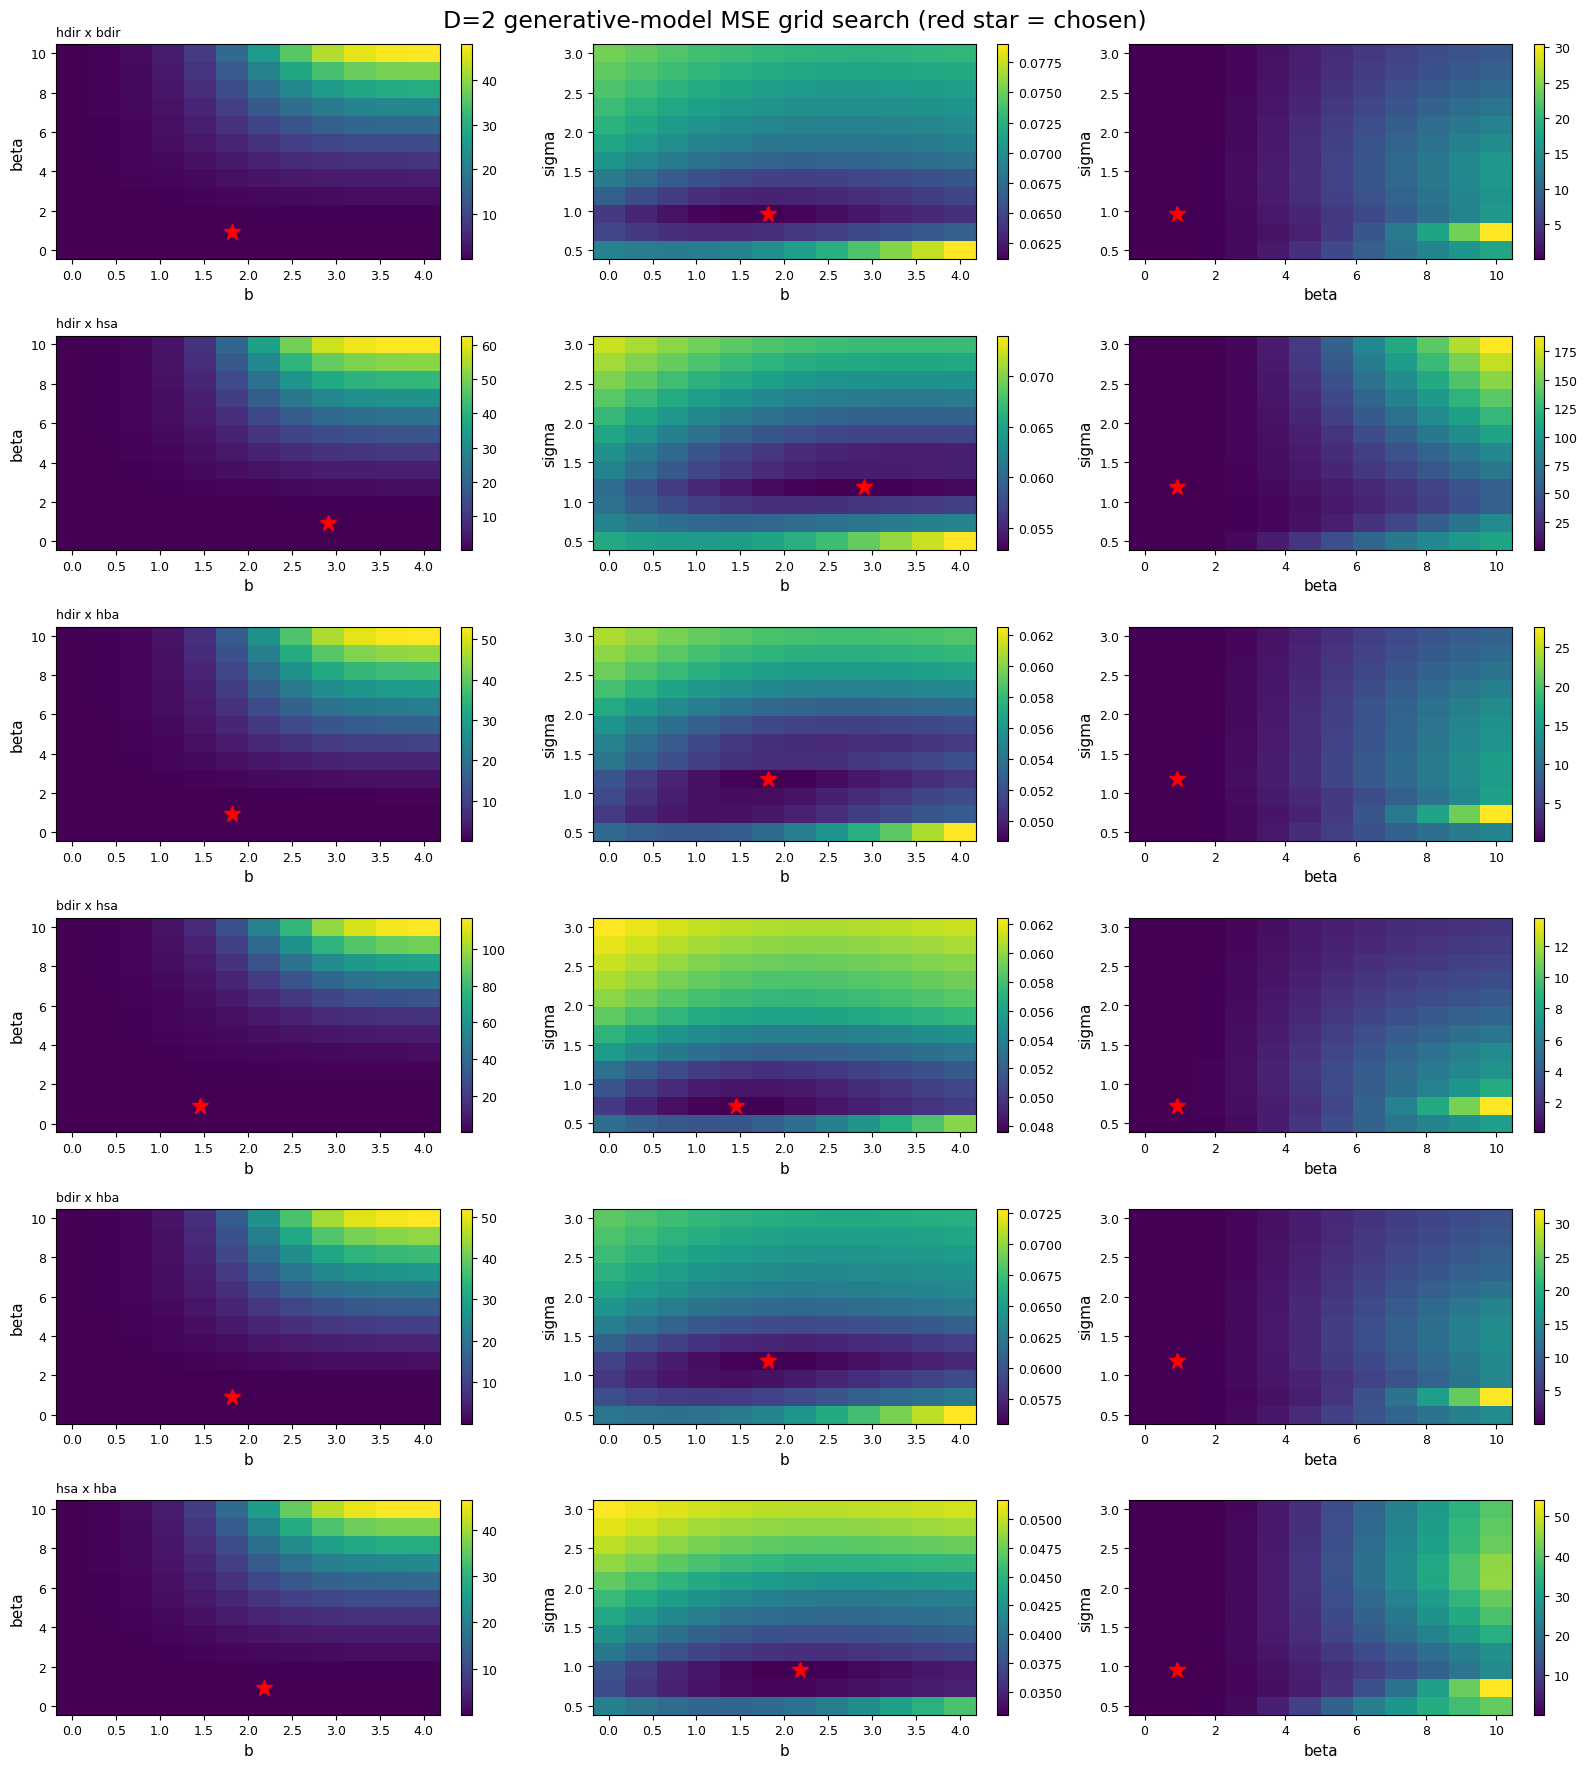

In [57]:
d = RES[2]; gen = d['gen']
sv, bv, bbv = gen['sigma_values'], gen['beta_values'], gen['b_values']
fig, axes = plt.subplots(len(d['tuples']), 3, figsize=ITEM8['figsize'])
for j, (p, q) in enumerate(d['tuples']):
    mse = gen['mse'][..., j]; i_s, i_be, i_b = gen['best_params']['index'][j]
    slices = [(mse[i_s, :, :], (bbv, bv), 'b', 'beta', i_b, i_be),
              (mse[:, i_be, :], (bbv, sv), 'b', 'sigma', i_b, i_s),
              (mse[:, :, i_b], (bv, sv), 'beta', 'sigma', i_be, i_s)]
    for ax, (mat, (xv, yv), xl, yl, ix, iy) in zip(axes[j], slices):
        im = ax.pcolormesh(xv, yv, mat, cmap=ITEM8['cmap'], shading='nearest')
        ax.plot(xv[ix], yv[iy], 'r*', ms=12); ax.set_xlabel(xl); ax.set_ylabel(yl)
        fig.colorbar(im, ax=ax, fraction=0.046)
    axes[j, 0].set_title(f"{BEHAVE[p]} x {BEHAVE[q]}", loc='left', fontsize=FONT['tick'])
fig.suptitle('D=2 generative-model MSE grid search (red star = chosen)')
fig.tight_layout(); finalize(fig, 'D2_item8_gridsearch')

# D = 4

### 9-13. The four-dimensional joint tuning

For D=4 there is a single tuning basis (all four variables jointly). The
`B**4` grid is shown reshaped to a `B**2 x B**2` image.

In [58]:
ITEM9 = dict(n_curves=6, figsize=(16, 3), seed=0, cmap=CMAP_TUNE,
             sizes=[10, 50, 200, 1000], n_samples_sweep=400)

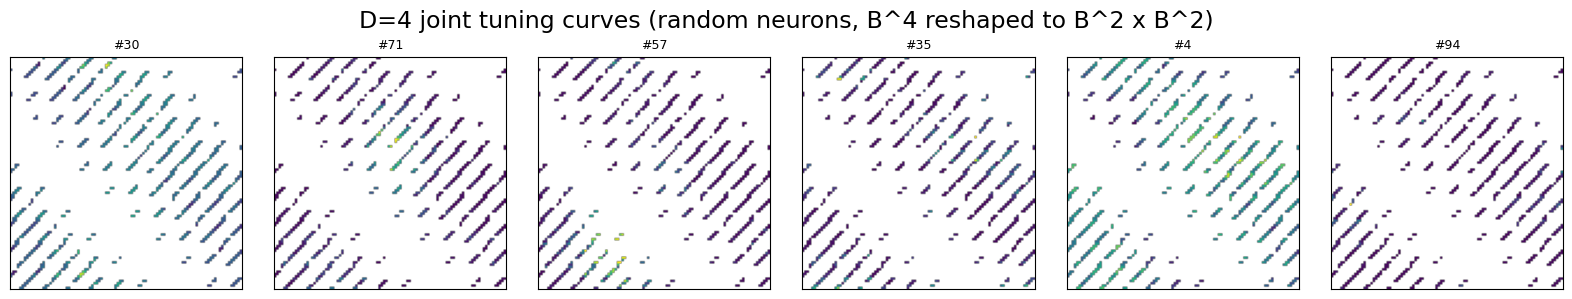

In [59]:
d = RES[4]; B = d['n_bins']; M = B ** 4; side = B * B
rng = np.random.default_rng(ITEM9['seed'])
F = d['F'][:, 0, :]

# 9. random 4-D tuning curves (reshaped to B^2 x B^2)
valid = np.where(np.isfinite(F).any(1))[0]
pick = rng.choice(valid, size=min(ITEM9['n_curves'], valid.size), replace=False)
fig, axes = plt.subplots(1, len(pick), figsize=ITEM9['figsize'])
for c, n in enumerate(pick):
    axes[c].imshow(F[n].reshape(side, side), origin='lower', cmap=ITEM9['cmap'])
    axes[c].set_xticks([]); axes[c].set_yticks([]); axes[c].set_title(f'#{n}', fontsize=FONT['tick'])
fig.suptitle('D=4 joint tuning curves (random neurons, B^4 reshaped to B^2 x B^2)')
fig.tight_layout(); finalize(fig, 'D4_item9_curves')

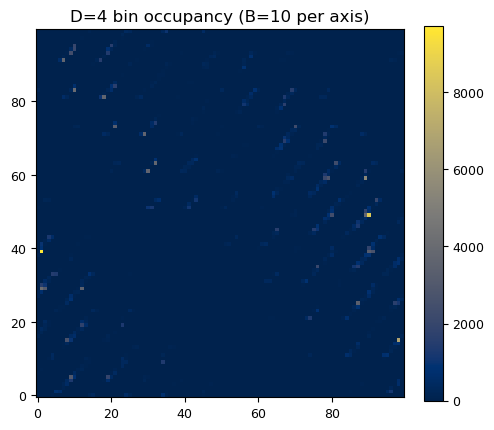

In [60]:
# 10. bin counts
d = RES[4]; B = d['n_bins']; side = B * B
fig, ax = plt.subplots(figsize=(5, 4.5))
im = ax.imshow(d['counts'][0].reshape(side, side), origin='lower', cmap='cividis')
ax.set_title(f'D=4 bin occupancy (B={B} per axis)'); fig.colorbar(im, ax=ax, fraction=0.046)
fig.tight_layout(); finalize(fig, 'D4_item10_counts')

D=4 grid search:   0%|          | 0/1728 [00:00<?, ?param/s]

D=4 grid search:   0%|          | 0/1728 [00:00<?, ?param/s]

D=4 grid search:   0%|          | 0/1728 [00:00<?, ?param/s]

D=4 grid search:   0%|          | 0/1728 [00:00<?, ?param/s]

D=4 grid search:   0%|          | 0/1728 [00:00<?, ?param/s]

D=4 grid search:   0%|          | 0/1728 [00:00<?, ?param/s]

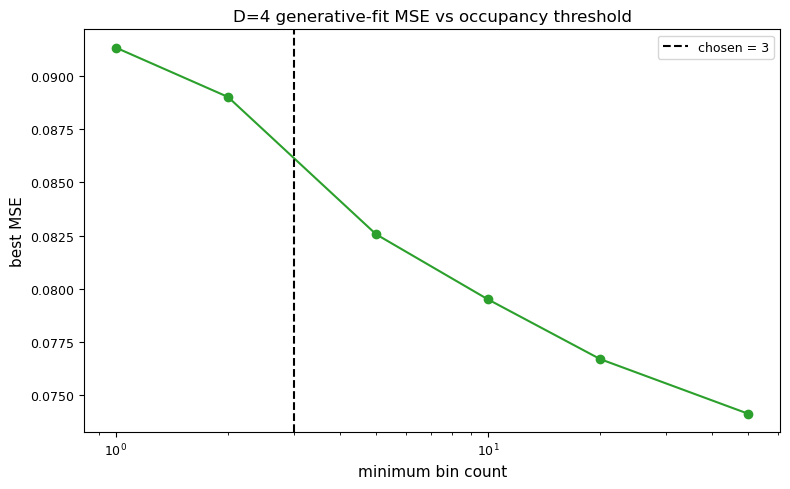

In [61]:
# 11. threshold sweep
d = RES[4]
sweep = []
for t in COUNT_SWEEP:
    g = L.fit_torus_generative_model(d['F'], d['counts'], d['n_bins'], 4,
            GEN_SIGMA, GEN_BETA, GEN_B, min_count=t, n_samples=ITEM9['n_samples_sweep'],
            seed=GEN_SEED, return_corr=False)
    sweep.append(g['best_params']['mse'][0])
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(COUNT_SWEEP, sweep, '-o', color=COLORS['D'][4])
ax.axvline(MIN_COUNT[4], ls='--', color='k', label=f"chosen = {MIN_COUNT[4]}")
ax.set_xlabel('minimum bin count'); ax.set_ylabel('best MSE'); ax.set_xscale('log'); ax.legend()
ax.set_title('D=4 generative-fit MSE vs occupancy threshold')
fig.tight_layout(); finalize(fig, 'D4_item11_threshold_sweep')

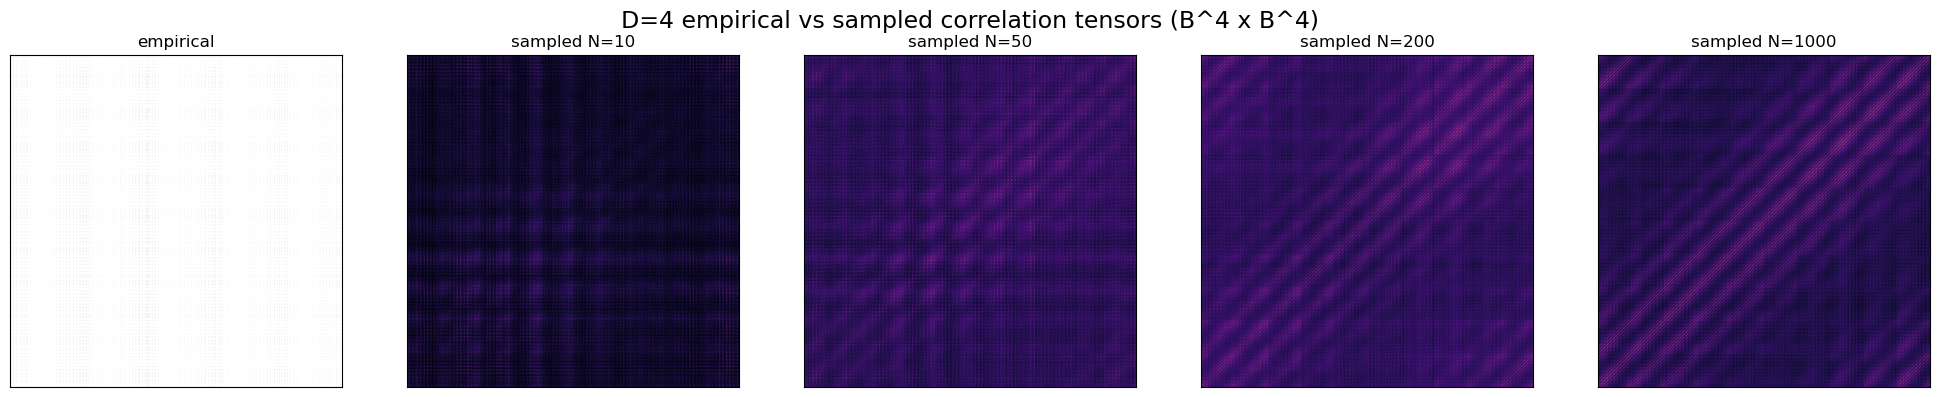

In [62]:
# 12. empirical correlation tensor (reshaped) and 13. sampled vs N
d = RES[4]; B = d['n_bins']; gp = d['gen']['best_params']; sizes = ITEM9['sizes']
fig, axes = plt.subplots(1, 1 + len(sizes), figsize=(4 * (1 + len(sizes)), 4))
im = axes[0].imshow(d['gen']['C'][0], origin='lower', cmap=CMAP_CORR)
axes[0].set_title('empirical'); axes[0].set_xticks([]); axes[0].set_yticks([])
for c, Nd in enumerate(sizes):
    rng = np.random.default_rng(2)
    Q = L.sample_torus_tuning_curves(gp['sigma'][0], gp['beta'][0], gp['b'][0],
                                     Nd, 1, B, 4, rng)[:, 0, :]
    Cc = (Q.T @ Q) / Nd
    axes[c + 1].imshow(Cc, origin='lower', cmap=CMAP_CORR)
    axes[c + 1].set_title(f'sampled N={Nd}'); axes[c + 1].set_xticks([]); axes[c + 1].set_yticks([])
fig.suptitle('D=4 empirical vs sampled correlation tensors (B^4 x B^4)')
fig.tight_layout(); finalize(fig, 'D4_item12_corr')

# Comparing D = 1, 2, 4

### 14. Cross-validated tuning vs L2-regression tuning

For each (neuron, basis) we correlate the cross-validated GP tuning `F[i,p,:]`
with the one-hot L2-regression tuning `W[i,p,:]` across grid cells. Each dot is
one (neuron, basis) combination.

In [63]:
ITEM14 = dict(figsize=(8, 5), point_size=8, alpha=0.4, seed=0)

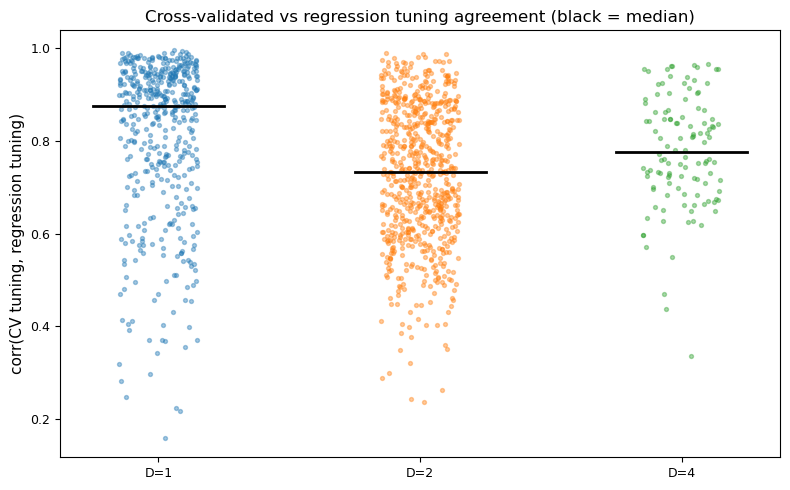

In [64]:
def _corr_along_cells(F, W):
    """Per (neuron, basis) Pearson correlation between F and W across cells."""
    N, nb, M = F.shape
    out = np.full((N, nb), np.nan)
    for n in range(N):
        for j in range(nb):
            a, b = F[n, j], W[n, j]
            m = np.isfinite(a) & np.isfinite(b)
            if m.sum() >= 3 and np.std(a[m]) > 0 and np.std(b[m]) > 0:
                out[n, j] = np.corrcoef(a[m], b[m])[0, 1]
    return out.ravel()

rng = np.random.default_rng(ITEM14['seed'])
fig, ax = plt.subplots(figsize=ITEM14['figsize'])
data = {}
for k, D in enumerate((1, 2, 4)):
    c = _corr_along_cells(RES[D]['F'], RES[D]['W'])
    c = c[np.isfinite(c)]; data[D] = c
    xj = k + (rng.random(c.size) - 0.5) * 0.3
    ax.scatter(xj, c, s=ITEM14['point_size'], alpha=ITEM14['alpha'], color=COLORS['D'][D])
    ax.plot([k - 0.25, k + 0.25], [np.median(c)] * 2, 'k-', lw=2)
ax.set_xticks([0, 1, 2]); ax.set_xticklabels(['D=1', 'D=2', 'D=4'])
ax.set_ylabel('corr(CV tuning, regression tuning)')
ax.set_title('Cross-validated vs regression tuning agreement (black = median)')
fig.tight_layout(); finalize(fig, 'cmp_item14_tuning_corr')

### 15. Variance explained by each tuning basis

Held-out variance explained for each D-model, computed two ways:

- **one-hot basis** — ridge regression onto the one-hot bin encoding of the
  joint cells (a free per-bin tuning is re-fit by L2; `D1` weights per variable),
  matching the "real tuning curves" reference in clark-presentation.ipynb;
- **fixed CV tuning** — each neuron's own cross-validated tuning curve used as a
  single scaled predictor per basis (1 weight per basis).

The one-hot basis has many more degrees of freedom, so it explains substantially
more variance; this is the reason the D=1 number here (one-hot) lines up with the
~20-25% reported in clark-presentation.ipynb, whereas the fixed-curve metric is
lower (~13%). Bin resolution (`N_BINS`) is a secondary factor.

In [65]:
ITEM15 = dict(figsize=(8, 5), l2=1e-2, test_frac=0.5, split_seed=0, max_T=40000)

D=1: VE = 0.1326
D=2: VE = 0.1968
D=4: VE = 0.2060


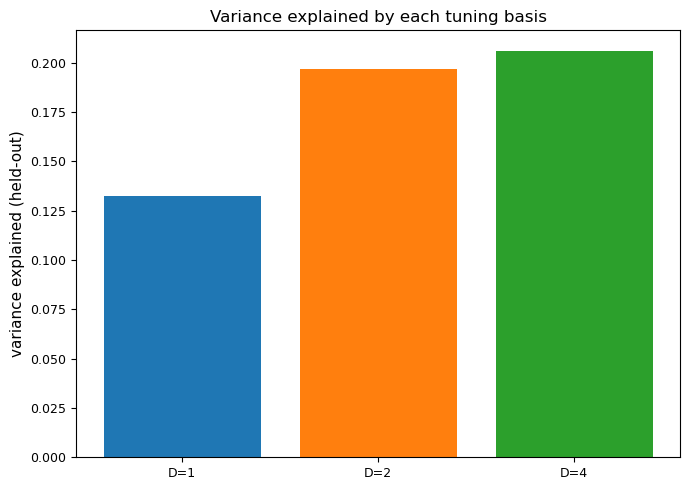

In [66]:
X, Bv, _ = load_session(ANIMAL, SESSION)
rng = np.random.default_rng(0); T = X.shape[1]
sub = np.sort(rng.choice(T, size=min(ITEM15['max_T'], T), replace=False))
Xs = X[:, sub]

def joint_cell(bin_idx, vt, B):
    """Flattened joint-cell index along the (sub-sampled) trajectory (-1 invalid)."""
    Dd = len(vt)
    valid = np.all([bin_idx[v] >= 0 for v in vt], axis=0)
    cell = np.zeros(bin_idx.shape[1], int)
    for k, v in enumerate(vt):
        cell += np.where(bin_idx[v] >= 0, bin_idx[v], 0) * (B ** (Dd - 1 - k))
    return np.where(valid, cell, -1)

ve_onehot, ve_cv = {}, {}
for D in (1, 2, 4):
    d = RES[D]; B = d['n_bins']; tuples = d['tuples']
    bin_idx, _ = L.bin_behaviour(Bv[:, sub], B)
    # (a) one-hot tuning-basis design (free per-bin tuning), occupied cells only
    cols, cv_design = [], np.full((Xs.shape[0], len(tuples), sub.size), np.nan)
    for j, vt in enumerate(tuples):
        cell = joint_cell(bin_idx, vt, B)
        occ = np.unique(cell[cell >= 0])
        cols.append((cell[None, :] == occ[:, None]).astype(float))     # (n_occ, Tsub)
        # (b) the fixed cross-validated tuning evaluated along the trajectory
        g = d['F'][:, j, :][:, np.where(cell >= 0, cell, 0)]
        g[:, cell < 0] = np.nan; cv_design[:, j, :] = g
    ve_onehot[D], _ = L.ridge_ve_shared_basis(Xs, np.vstack(cols), l2=ITEM15['l2'],
                                              test_frac=ITEM15['test_frac'], split_seed=ITEM15['split_seed'])
    ve_cv[D], _ = L.ridge_ve_per_neuron(Xs, cv_design, l2=ITEM15['l2'],
                                        test_frac=ITEM15['test_frac'], split_seed=ITEM15['split_seed'])
    print(f"D={D}: one-hot basis VE = {ve_onehot[D]:.4f} | fixed CV tuning VE = {ve_cv[D]:.4f}")

x = np.arange(3); w = 0.38
fig, ax = plt.subplots(figsize=ITEM15['figsize'])
ax.bar(x - w / 2, [ve_onehot[D] for D in (1, 2, 4)], w, label='one-hot basis (free per-bin)',
       color=[COLORS['D'][D] for D in (1, 2, 4)])
ax.bar(x + w / 2, [ve_cv[D] for D in (1, 2, 4)], w, label='fixed CV tuning',
       color=[COLORS['D'][D] for D in (1, 2, 4)], alpha=0.5)
ax.set_xticks(x); ax.set_xticklabels(['D=1', 'D=2', 'D=4'])
ax.set_ylabel('variance explained (held-out)'); ax.legend()
ax.set_title('Variance explained by each tuning basis')
fig.tight_layout(); finalize(fig, 'cmp_item15_variance_explained')